In [21]:
import pandas as pd
import seaborn as sns

In [4]:
#importing data/csv
df = pd.read_csv("../data/raw/credit_card_transactions.csv")

In [13]:
#overall a general look of what the dataset looks like
print("df_shape=",df.shape)
pd.set_option('display.max_columns', None)
df.head()


# useful data you might want to explore
# (is_fraud) (amt) (trans_date_trans_time)


df_shape= (1296675, 24)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [ ]:
# more descriptive scripts
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode'],
      dtype='str')

In [19]:
# finding fraud detection class imbalance
df["is_fraud"].value_counts()

# finding missing values
df.isna().sum()

# number of unique values
df.nunique()



Unnamed: 0               1296675
trans_date_trans_time    1274791
cc_num                       983
merchant                     693
category                      14
amt                        52928
first                        352
last                         481
gender                         2
street                       983
city                         894
state                         51
zip                          970
lat                          968
long                         969
city_pop                     879
job                          494
dob                          968
trans_num                1296675
unix_time                1274823
merch_lat                1247805
merch_long               1275745
is_fraud                       2
merch_zipcode              28336
dtype: int64

<Axes: >

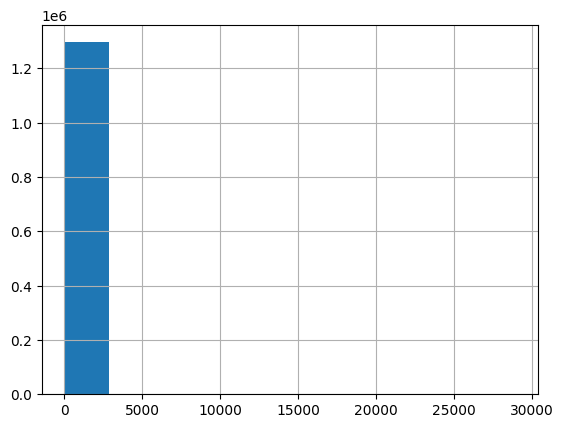

In [20]:
# looking at distributions of certain columns:
df["amt"].hist()

### Some interesting things from inital EDA of the data set
- Large Dataset (1.2 mil transactions)
- Massive Class Imbalance in "is_fraud" - only 7,506 fraudulent transactions
- `cc-num` unique value is only 983, only 983 unique customers
- `job` unique job is only 494 so pretty diverse range of jobs. model could potentially have trouble generliziing data.

### Hypothesis on the overal project:
1) Fraudulent activity mainly happens at night
2) Some states or some cities might have more fraudulent activies than other
3) When fraud happens, it's mostly in large amounts. Place emphasis on `amt`

### Sources of non-gereralizable/useless features:
1) `trans_num`  -  pretty useless info that the model could possibly memorize
2) `unix_time`  -  useless number but feature engineer it into exact time stamps later
3) `trans_date_trans_time`  -  again pretty useless and bloated for a model to take in. Feature engieer it into time stamps later
4) `cc_num`  -  useless credit card info. model could memorize.
5) `merch_zipcode`  -  to many different types of data and not generalizable.

### Useful sources of data:
1) `category`
2) `amt`
3) `job`
4) `dob`
5) `city_pop`
6) `gender`
7) `state`

### Possibly useful source of data:
Combine `merch_lat` `merch_long` with `lat` `long`
Use this information to engineer a feature that maybe:
- Distance between merchant and buyer? something to think about later



